# Import Libraries

In [1]:
# Run once if packages are missing
# !pip install imbalanced-learn shap xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Load Data

In [2]:
df = pd.read_csv('cs-training.csv', index_col=0)

print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Class Imbalance

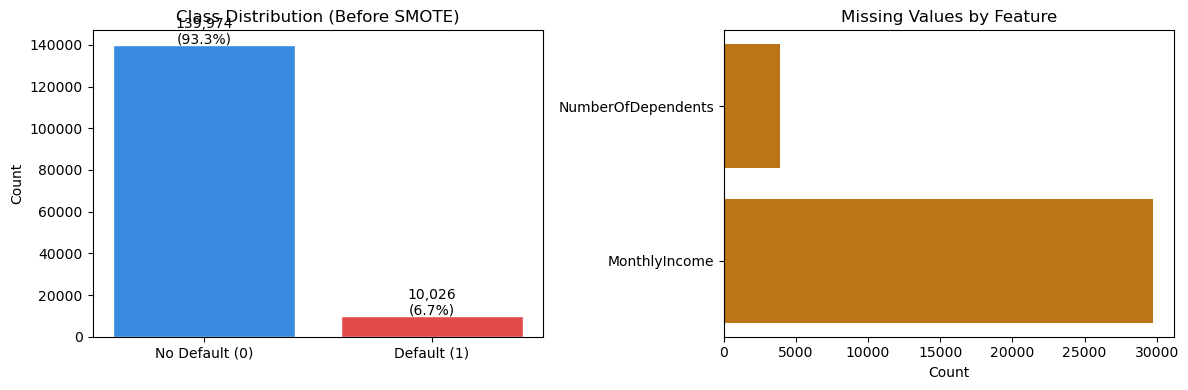

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution bar chart
counts = df['SeriousDlqin2yrs'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], counts.values,
            color=['#378ADD', '#E24B4A'], edgecolor='white')
axes[0].set_title('Class Distribution (Before SMOTE)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
axes[1].barh(missing.index, missing.values, color='#BA7517')
axes[1].set_title('Missing Values by Feature')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

# Preprocessing 

In [4]:
# Drop rows where target is null
df = df.dropna(subset=['SeriousDlqin2yrs'])

# Fill missing values with median (robust to outliers)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

# Remove extreme outliers in age (bad data)
df = df[(df['age'] >= 18) & (df['age'] <= 100)]

# Feature / target split
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

print("Features:", X.columns.tolist())
print("Class balance:\n", y.value_counts())

Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Class balance:
 SeriousDlqin2yrs
0    139961
1     10025
Name: count, dtype: int64


# Correlation Heatmap

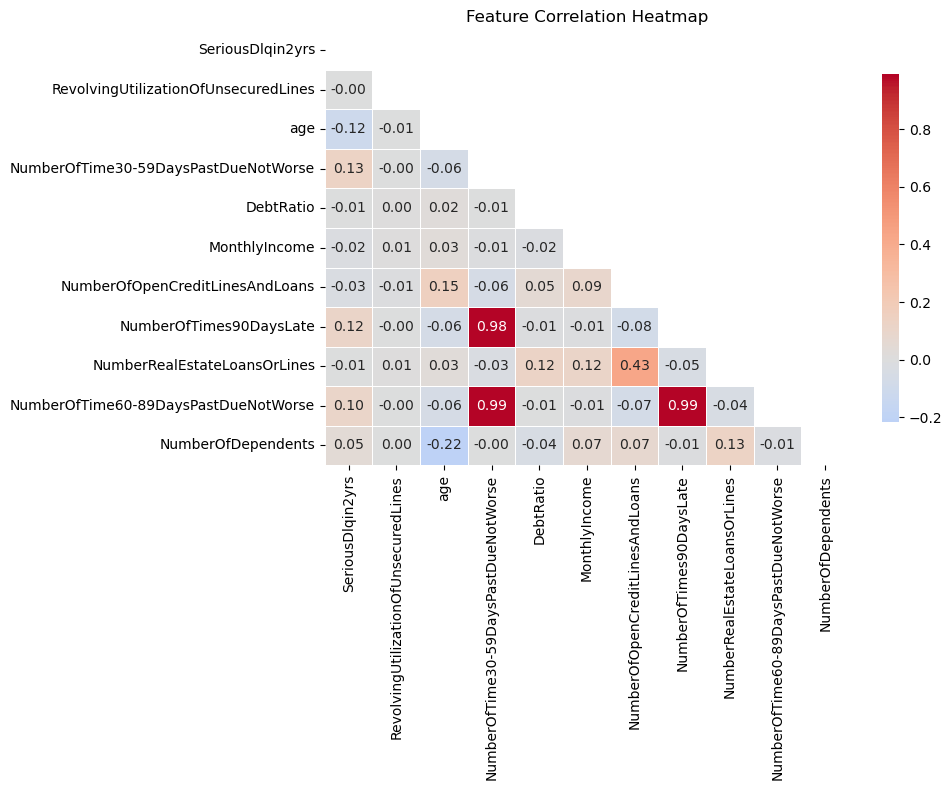

In [5]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Train/test split & SMOTE

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

# Scale for Logistic Regression and SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

Before SMOTE: {0: 111968, 1: 8020}
After SMOTE:  {0: 111968, 1: 111968}


# Train all 4 models

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=5,
                                         learning_rate=0.1, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42),
    'Naive Bayes':         GaussianNB()
}

# LR and SVM use scaled data; tree-based don't need it
scaled_models = {'Logistic Regression', 'SVM'}

results = {}
for name, model in models.items():
    Xtr = X_train_sc if name in scaled_models else X_train_sm
    Xte = X_test_sc  if name in scaled_models else X_test
    model.fit(Xtr, y_train_sm)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba}
    print(f"\n{'='*40}\n{name}\n{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))


Logistic Regression
              precision    recall  f1-score   support

  No Default       0.96      0.66      0.78     27993
     Default       0.12      0.65      0.20      2005

    accuracy                           0.66     29998
   macro avg       0.54      0.65      0.49     29998
weighted avg       0.91      0.66      0.74     29998


Decision Tree
              precision    recall  f1-score   support

  No Default       0.97      0.84      0.90     27993
     Default       0.21      0.59      0.31      2005

    accuracy                           0.83     29998
   macro avg       0.59      0.72      0.61     29998
weighted avg       0.92      0.83      0.86     29998


XGBoost
              precision    recall  f1-score   support

  No Default       0.96      0.90      0.93     27993
     Default       0.27      0.52      0.36      2005

    accuracy                           0.87     29998
   macro avg       0.62      0.71      0.64     29998
weighted avg       0.92      

# Confusion Matrices (2x2)

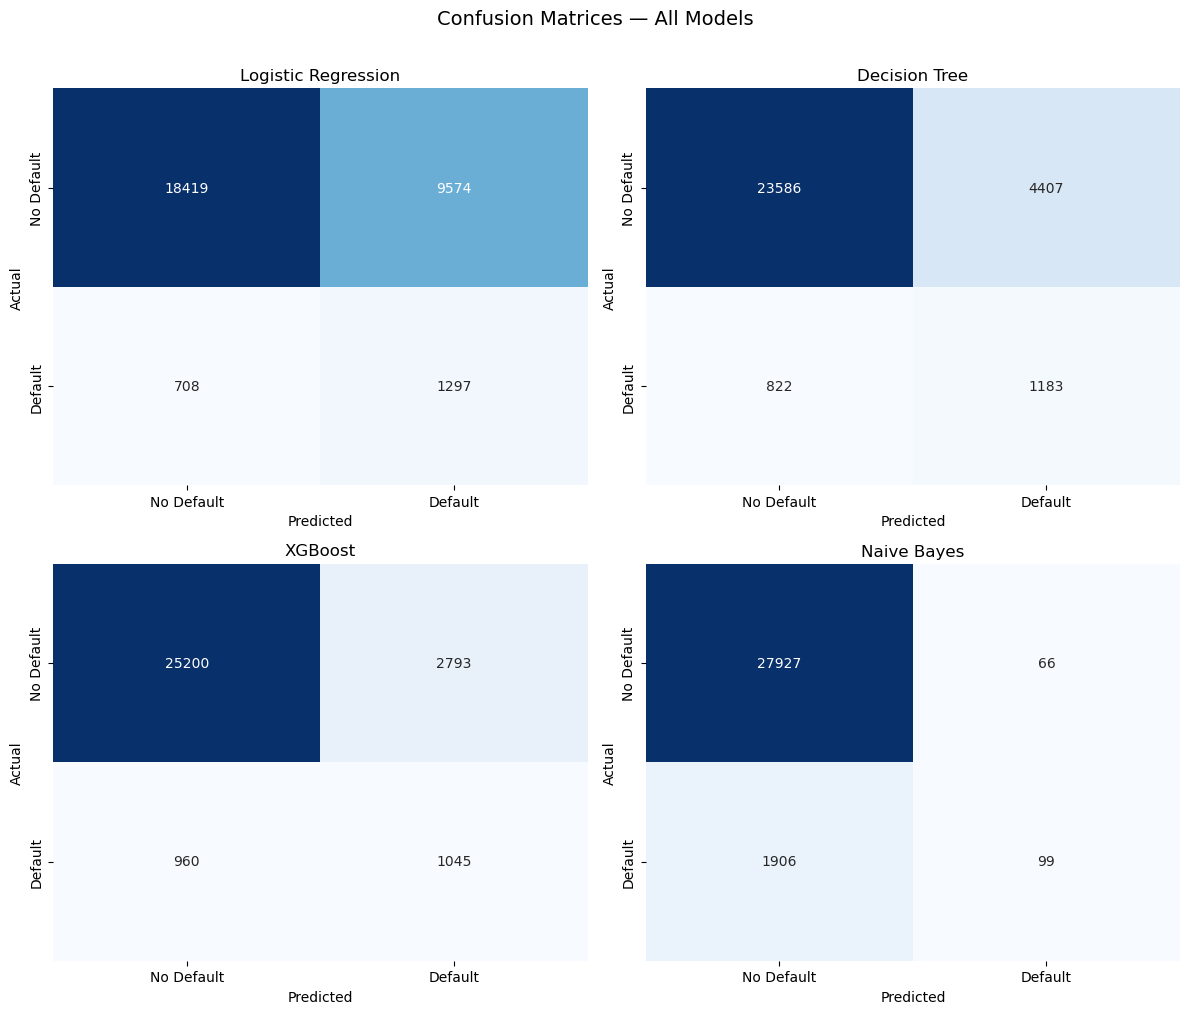

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'],
                ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ROC Curves

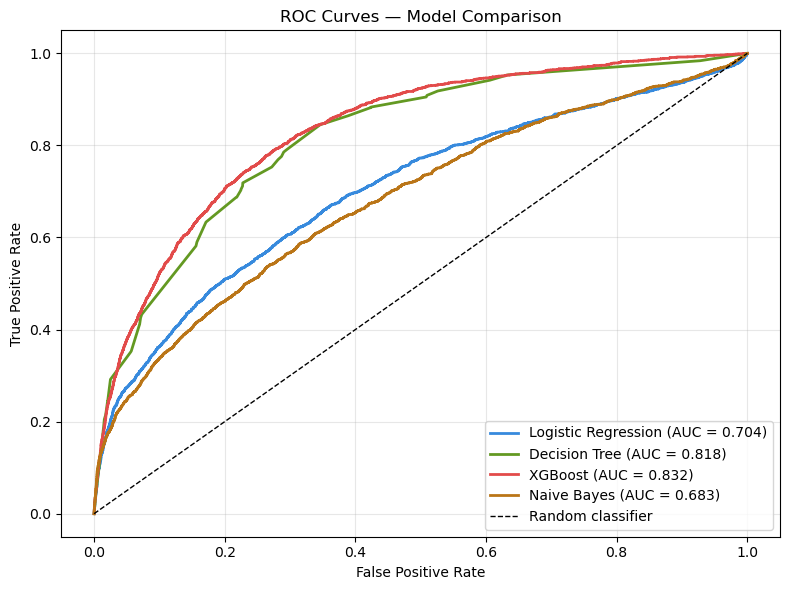

In [9]:
plt.figure(figsize=(8, 6))
colors = ['#378ADD', '#639922', '#E24B4A', '#BA7517']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc = roc_auc_score(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Precision Recall Curves

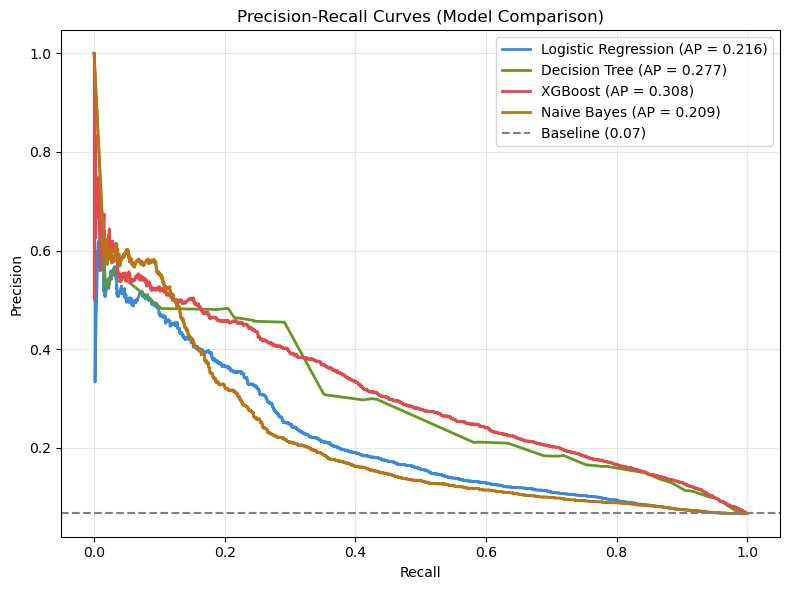

In [14]:
plt.figure(figsize=(8,6))
colors = ['#378ADD', '#639922', '#E24B4A', '#BA7517']

for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ap = average_precision_score(y_test, res['y_proba'])
    plt.plot(rec, prec, label=f'{name} (AP = {ap:.3f})', color=color, lw=2)

baseline = y_test.mean()
plt.axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Model Comparison)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()